**Project Title: Customer Churn Prediction for Subscription Services**


Introduction
Customer churn, the phenomenon of customers discontinuing their service or subscription, is a critical challenge for businesses, particularly in subscription-based models. High churn rates can significantly impact revenue, profitability, and growth. Identifying customers at risk of churning allows businesses to implement targeted retention strategies, thereby improving customer lifetime value and overall business health.

This project aims to develop a robust machine learning model to predict customer churn for a subscription-based service.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/customer_churn_data/customer_churn_data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [7]:
# Drop 'customerID' as it's an identifier and not useful for modeling
df_processed = df.drop('customerID', axis=1)

# Separate target variable
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### Encode Categorical Features

We'll use one-hot encoding for categorical features.

In [8]:
from sklearn.preprocessing import OneHotEncoder

# Apply one-hot encoding to categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded ones
X_encoded = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)

# Convert target variable 'Churn' to numerical (Yes=1, No=0)
y_encoded = y.apply(lambda x: 1 if x == 'Yes' else 0)

print("Shape of X after encoding:", X_encoded.shape)
display(X_encoded.head())

Shape of X after encoding: (5880, 45)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,23,49.85,1146.55,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0,43,100.70,4330.10,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,51,97.33,4963.83,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1,72,101.38,7299.36,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1,25,52.22,1305.50,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Feature Scaling

Scaling numerical features is important for many machine learning algorithms. We'll use `StandardScaler`.

In [9]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (these are the original numerical columns)
# after one-hot encoding, they are still present in X_encoded
numerical_features_to_scale = X_encoded[numerical_cols]

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(numerical_features_to_scale)

print("X after scaling numerical features:")
display(X_encoded.head())

X after scaling numerical features:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.001361,-0.648040,-0.705078,-0.743650,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,-1.001361,0.308537,1.060414,0.923257,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.998640,0.691167,0.943409,1.255078,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.998640,1.695572,1.084023,2.477961,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.998640,-0.552382,-0.622793,-0.660423,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Split Data into Training and Testing Sets

We'll split the data into 80% for training and 20% for testing.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train distribution:\n", y_train.value_counts(normalize=True))
print("\ny_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (4704, 45)
X_test shape: (1176, 45)
y_train shape: (4704,)
y_test shape: (1176,)

y_train distribution:
 Churn
0    0.507228
1    0.492772
Name: proportion, dtype: float64

y_test distribution:
 Churn
0    0.506803
1    0.493197
Name: proportion, dtype: float64


## Step 4: Model Development

### Logistic Regression Model

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC AUC Score: {roc_auc_log_reg:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.5009
Precision: 0.4925
Recall: 0.3966
F1-Score: 0.4394
ROC AUC Score: 0.4748


### Random Forest Classifier

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

Random Forest Classifier Model Performance:
Accuracy: 0.5051
Precision: 0.4982
Recall: 0.4741
F1-Score: 0.4859
ROC AUC Score: 0.5009


## Step 2: Exploratory Data Analysis (EDA)

### Check for Missing Values

In [17]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values and their counts
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Columns with missing values:")
    display(missing_values)
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


### Check for Duplicate Rows

In [14]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
else:
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


## Visualizing Churn Patterns and Model Performance

### Churn by Contract Type

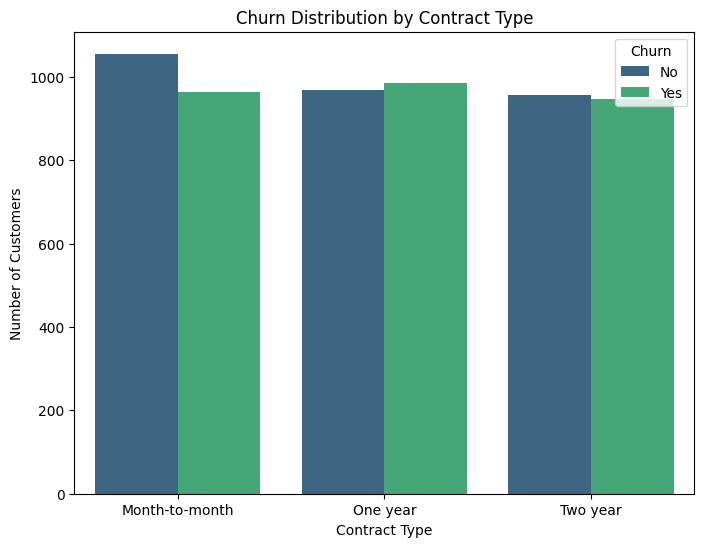

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Churn by Internet Service Type

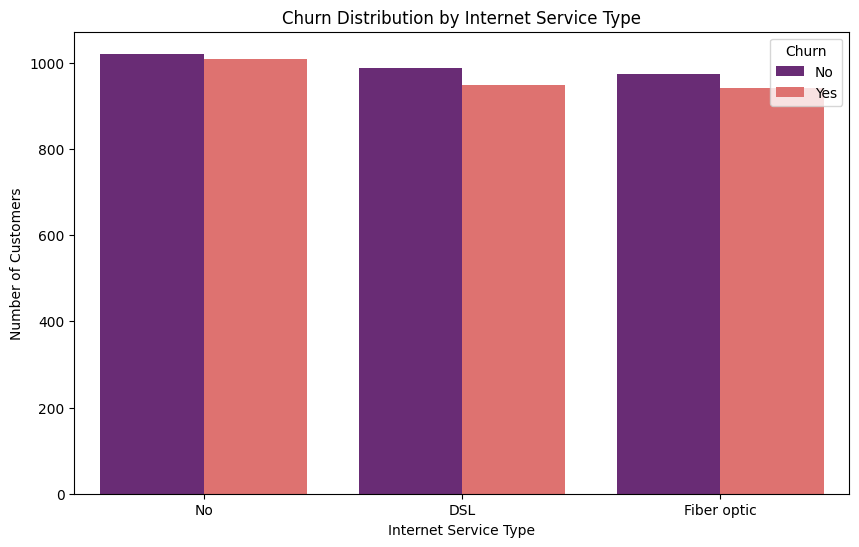

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma')
plt.title('Churn Distribution by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

### Churn by Monthly Charges Distribution

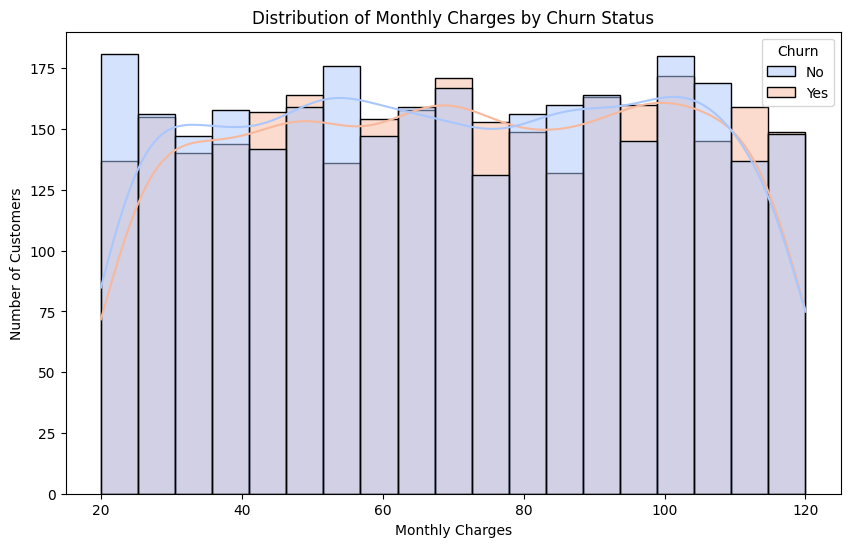

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
import pandas as pd

# Create a dictionary to store model performance
performance_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_log_reg, accuracy_rf, accuracy_gbc],
    'Precision': [precision_log_reg, precision_rf, precision_gbc],
    'Recall': [recall_log_reg, recall_rf, recall_gbc],
    'F1-Score': [f1_log_reg, f1_rf, f1_gbc],
    'ROC AUC Score': [roc_auc_log_reg, roc_auc_rf, roc_auc_gbc]
}

# Create a DataFrame from the performance data
performance_df = pd.DataFrame(performance_data)

# Display the performance table, sorted by ROC AUC Score
print("\n--- Model Performance Comparison ---")
display(performance_df.sort_values(by='ROC AUC Score', ascending=False))


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
1,Random Forest,0.505102,0.498188,0.474138,0.485866,0.500907
0,Logistic Regression,0.500850,0.492505,0.396552,0.439351,0.474841
2,Gradient Boosting,0.480442,0.472072,0.451724,0.461674,0.463472


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbc = gbc_model.predict(X_test)
y_pred_proba_gbc = gbc_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_pred_proba_gbc)

print("Gradient Boosting Classifier Model Performance:")
print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC AUC Score: {roc_auc_gbc:.4f}")

Gradient Boosting Classifier Model Performance:
Accuracy: 0.4804
Precision: 0.4721
Recall: 0.4517
F1-Score: 0.4617
ROC AUC Score: 0.4635


### ROC Curves for All Models

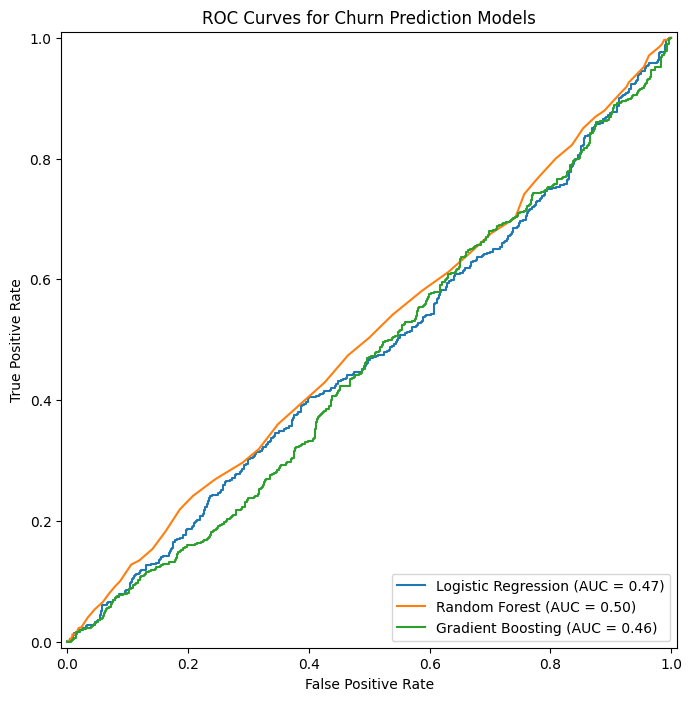

In [22]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(gbc_model, X_test, y_test, ax=ax, name='Gradient Boosting')

plt.title('ROC Curves for Churn Prediction Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

### Confusion Matrix for Random Forest (Best Model by ROC AUC)

<Figure size 800x600 with 0 Axes>

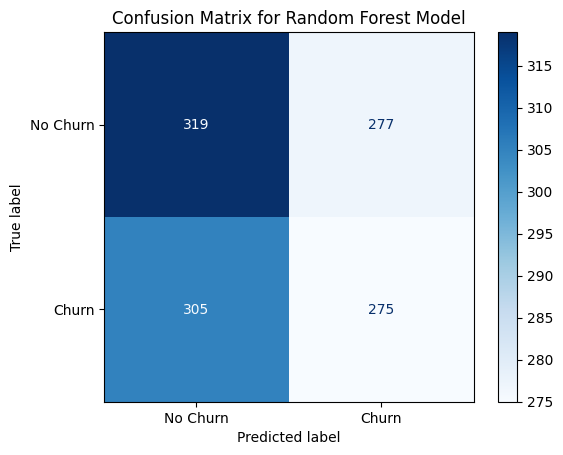

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp_rf.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

In [24]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


In [25]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n")
print(df.dtypes)
print("\nMissing Values:\n")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (5880, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:



In [ ]:
df['Churn'].value_counts()

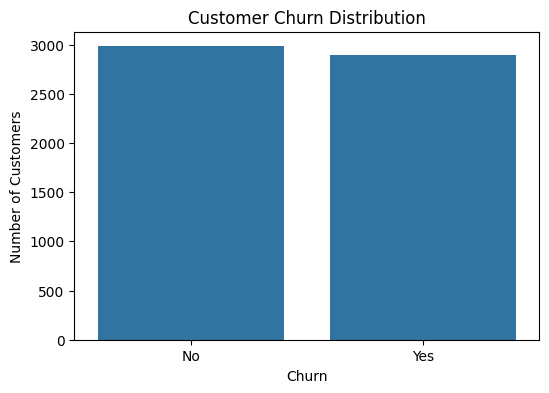

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


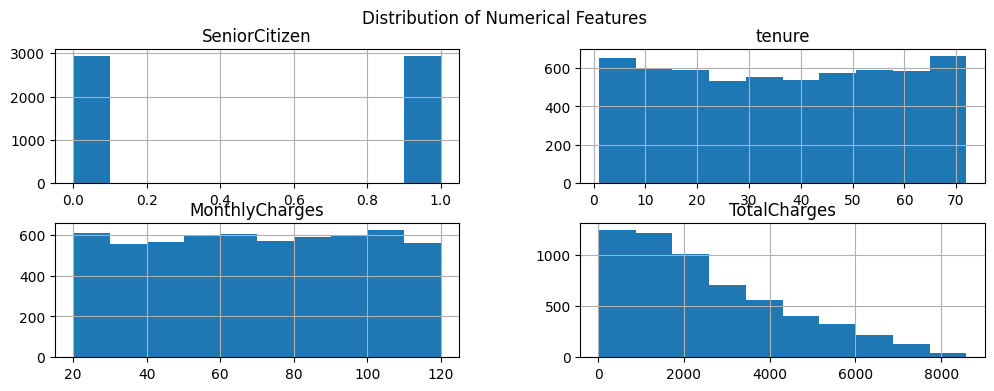

In [27]:
df[numerical_cols].hist(figsize=(12,4))
plt.suptitle("Distribution of Numerical Features")
plt.show()

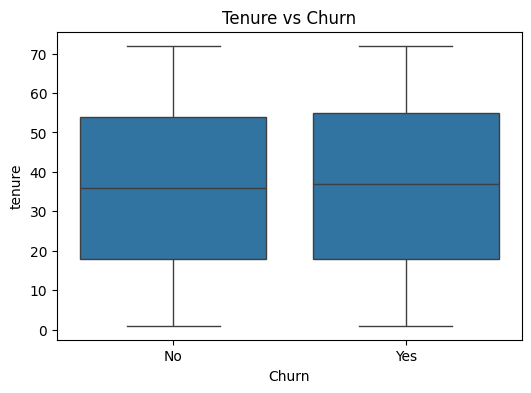

In [28]:
#Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X_df) and target (y_df) from the original DataFrame for pipeline usage
X_df = df.drop(['customerID', 'Churn'], axis=1)
y_df = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Define numerical_cols and categorical_cols based on the *processed* X_df
categorical_cols_pipeline = X_df.select_dtypes(include='object').columns
numerical_cols_pipeline = X_df.select_dtypes(include=['int64', 'float64']).columns

# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_pipeline),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_pipeline)
    ],
    remainder='drop' # Drop any columns not explicitly transformed
)

# Create the pipeline with the preprocessor and Logistic Regression model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Split data *after* defining X_df and y_df for consistency with pipeline
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_df, y_df, test_size=0.2, random_state=42, stratify=y_df
)

logistic_model.fit(X_train_pipe, y_train_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred_log = logistic_model.predict(X_test_pipe)

In [33]:
from sklearn.metrics import recall_score, f1_score, classification_report

# Correcting the variable name from y_pred_log to y_pred_log_reg
recall_log = recall_score(y_test, y_pred_log_reg)
f1_log = f1_score(y_test, y_pred_log_reg)

print("Logistic Regression Recall:", recall_log)
print("Logistic Regression F1 Score:", f1_log)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Recall: 0.39655172413793105
Logistic Regression F1 Score: 0.4393505253104107

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.60      0.55       596
           1       0.49      0.40      0.44       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.49      1176
weighted avg       0.50      0.50      0.50      1176



In [34]:
# TRAIN RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# Use X_train_pipe and y_train_pipe which contain raw data for the pipeline
rf_model.fit(X_train_pipe, y_train_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

**Model 2: Random Forest**
Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions. It can capture complex relationships between features and often performs better than linear models for classification tasks.

TRAIN RANDOM FOREST MODEL

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# Use X_train_pipe and y_train_pipe which contain raw data for the pipeline
rf_model.fit(X_train_pipe, y_train_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [36]:
# RANDOM FOREST PREDICTIONS

y_pred_rf = rf_model.predict(X_test_pipe)

In [37]:
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Recall:", recall_rf)
print("Random Forest F1 Score:", f1_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Recall: 0.45
Random Forest F1 Score: 0.46153846153846156

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.51      0.50       596
           1       0.47      0.45      0.46       580

    accuracy                           0.48      1176
   macro avg       0.48      0.48      0.48      1176
weighted avg       0.48      0.48      0.48      1176



In [38]:
rf = rf_model.named_steps["model"]

importances = rf.feature_importances_

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
2,num__MonthlyCharges,0.147501
3,num__TotalCharges,0.145508
1,num__tenure,0.133673
0,num__SeniorCitizen,0.030486
40,cat__PaperlessBilling_Yes,0.020237
37,cat__Contract_One year,0.020116
42,cat__PaymentMethod_Credit card,0.020057
39,cat__PaperlessBilling_No,0.019999
8,cat__Dependents_No,0.019919
38,cat__Contract_Two year,0.019877


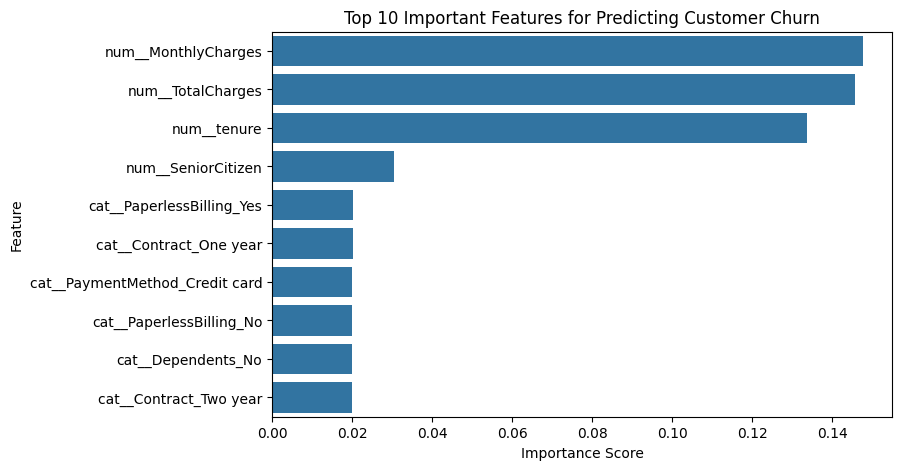

In [39]:

import matplotlib.pyplot as plt
import seaborn as sns

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=top_features)

plt.title("Top 10 Important Features for Predicting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, f1_score, classification_report

small_rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        random_state=42
    ))
])

# Use X_train_pipe and y_train_pipe which contain raw data for the pipeline
small_rf_model.fit(X_train_pipe, y_train_pipe)

# Use X_test_pipe for predictions
y_pred_small_rf = small_rf_model.predict(X_test_pipe)

# Note: y_test should correspond to y_test_pipe for accurate evaluation
recall_small_rf = recall_score(y_test_pipe, y_pred_small_rf)
f1_small_rf = f1_score(y_test_pipe, y_pred_small_rf)

print("Smaller Random Forest Recall:", recall_small_rf)
print("Smaller Random Forest F1 Score:", f1_small_rf)

print("\nClassification Report:\n")
print(classification_report(y_test_pipe, y_pred_small_rf))

Smaller Random Forest Recall: 0.42758620689655175
Smaller Random Forest F1 Score: 0.4517304189435337

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.55      0.52       596
           1       0.48      0.43      0.45       580

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176

